# Занятие 13. Кластеризация на простых данных: статистический взгляд на группы — методичка преподавателя

> **Цель занятия:** научиться находить в данных **естественные группы похожих объектов** без заранее заданных меток — измерять похожесть расстоянием, описывать группу её центром и выбирать число групп по простым числовым признакам.

**Что будет:**

1. Зачем группировать объекты и что такое кластеризация.
2. Признак и **расстояние** — как измерить похожесть двух объектов числом.
3. **Центроид** — среднее группы как её «портрет».
4. Два способа искать группы: **K-Means** и **иерархическая кластеризация** с дендрограммой.
5. Как выбрать **число групп** — метод локтя.

---
## 1. Зачем группировать объекты

Рассмотрим магазин с тысячами покупателей. Рассылать всем одинаковую рекламу неэффективно.
Если же разбить покупателей на **группы похожих**, каждой группе можно предложить релевантное предложение.

- Группа «школьники»: тратят мало, покупают часто, выбирают снеки.
- Группа «занятые взрослые»: тратят много, покупают редко, берут готовую еду.
- Группа «экономные пенсионеры»: ориентируются на скидки, покупают по списку.

В этом и состоит практическая ценность кластеризации.

**Кластеризация** — это разбиение объектов на группы (кластеры) так, чтобы:
- **внутри** одной группы объекты были **похожи** друг на друга;
- объекты из **разных** групп **отличались**.

Области применения: музыкальные сервисы группируют похожие композиции; розничные сети сегментируют покупателей; телефон группирует фотографии по лицам; в науке группируют схожие болезни или гены.

Ключевая особенность: кластеризация относится к **обучению без учителя**. Алгоритму не сообщают заранее возможные группы — он выделяет их **самостоятельно** на основе признаков объектов.

---
## 2. Признак и расстояние: как измерить похожесть

Чтобы алгоритм мог сравнивать объекты, их описывают **числами** — признаками.
Например, человека можно описать возрастом и тратами в месяц.

Каждый человек — это **точка** на графике: по горизонтали возраст, по вертикали траты.
Построим маленький понятный набор и посмотрим глазами, есть ли группы.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Маленький понятный набор данных: 4 человека
people = pd.DataFrame({
    'имя':     ['Аня', 'Боря', 'Вика', 'Гена'],
    'возраст': [15, 16, 45, 47],
    'траты':   [5, 6, 40, 38],
})
people

,имя,возраст,траты
0,Аня,15,5
1,Боря,16,6
2,Вика,45,40
3,Гена,47,38


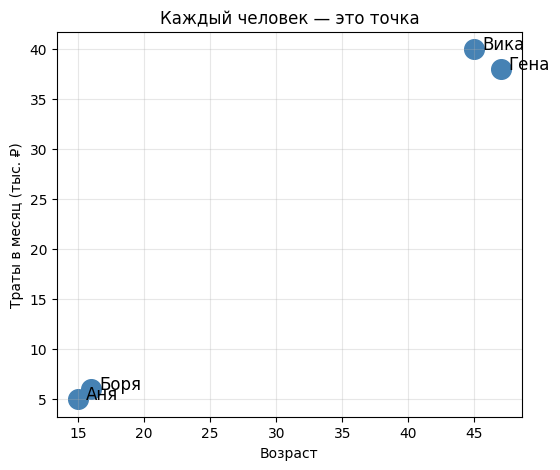

In [2]:
# Нарисуем каждого человека точкой
plt.figure(figsize=(6, 5))
plt.scatter(people['возраст'], people['траты'], s=200, c='steelblue')
for _, row in people.iterrows():
    plt.text(row['возраст'] + 0.6, row['траты'], row['имя'], fontsize=12)
plt.xlabel('Возраст'); plt.ylabel('Траты в месяц (тыс. ₽)')
plt.title('Каждый человек — это точка'); plt.grid(True, alpha=0.3)
plt.show()

**Вывод:** точки образуют **две группы** — Аня и Боря слева внизу (молодые, тратят мало), Вика и Гена справа вверху (старше, тратят много). Глазами группы видны; следующий шаг — формализовать «похожесть» числом.

Утверждение «Аня и Боря похожи» означает, что их точки расположены **близко**, то есть расстояние между ними **мало́**. Расстояние между двумя точками считается по **теореме Пифагора** — это **евклидово расстояние**:

$$ d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2} $$

In [3]:
def distance(a, b):
    # Евклидово расстояние между двумя точками (теорема Пифагора)
    return np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

anya, borya, vika = (15, 5), (16, 6), (45, 40)
print(f'Расстояние Аня–Боря: {distance(anya, borya):.1f}')
print(f'Расстояние Аня–Вика: {distance(anya, vika):.1f}')

Расстояние Аня–Боря: 1.4
Расстояние Аня–Вика: 46.1


**Вопрос:** какая пара объектов более похожа — Аня и Боря или Аня и Вика, и как это видно из посчитанного расстояния?

> Помимо евклидова, есть **манхэттенское** расстояние — сумма модулей разностей координат: $|x_1-x_2| + |y_1-y_2|$.

In [4]:
# Манхэттенское расстояние Аня–Боря
manhattan = abs(anya[0] - borya[0]) + abs(anya[1] - borya[1])
print('Манхэттенское расстояние Аня–Боря:', manhattan)

Манхэттенское расстояние Аня–Боря: 2


**Вывод:** манхэттенское расстояние = 2 (единица по возрасту плюс единица по тратам). Оно измеряет похожесть иначе, чем евклидово, но принцип тот же: меньше — значит похожее.

---
## 3. Центр группы (центроид)

У каждой группы есть **центр** — усреднённый объект. Чтобы его найти, берут **среднее** по каждому признаку. Такой центр называется **центроидом**. Он служит коротким «портретом» группы: один набор чисел вместо всех её объектов.

Посчитаем центр группы «молодые» (Аня и Боря).

In [5]:
young = people[people['имя'].isin(['Аня', 'Боря'])]
center_age = young['возраст'].mean()
center_spend = young['траты'].mean()
print(f'Центр группы «молодые»: возраст={center_age}, траты={center_spend}')

Центр группы «молодые»: возраст=15.5, траты=5.5


> **Подумайте:** что произойдёт с центроидом группы «молодые», если в неё добавить третьего человека 30 лет с тратами 20? Прикиньте направление сдвига, затем проверьте.

In [13]:
# young3 = pd.DataFrame({'возраст': [15, 16, 30], 'траты': [5, 6, 20]})
# print('Новый центр:', young3['возраст'].mean(), young3['траты'].mean())

---
## 4. Алгоритм K-Means

**K-Means** (метод *k-средних*) — один из самых распространённых методов кластеризации. Параметр **K** задаёт **число групп**, которое требуется получить (например, K = 2).

Алгоритм работает шагами:

1. **Инициализация.** K центров ставятся в случайные позиции.
2. **Распределение.** Каждый объект относится к *ближайшему* центру — образуются группы.
3. **Пересчёт.** Каждый центр переезжает в *середину* своей группы (в центроид).
4. **Повтор шагов 2–3**, пока центры не перестанут смещаться.

Посмотрим это по шагам на 8 точках.

In [7]:
# 8 точек: 4 "молодых" слева внизу и 4 "взрослых" справа вверху
pts = np.array([
    [15, 5], [16, 6], [14, 4], [17, 7],
    [45, 40], [47, 38], [44, 42], [48, 39],
], dtype=float)

centers = np.array([[20.0, 10.0], [40.0, 20.0]])  # стартуем специально неудачно

def assign(pts, centers):
    labels = []
    for p in pts:
        dists = [np.sqrt(((p - c)**2).sum()) for c in centers]
        labels.append(np.argmin(dists))
    return np.array(labels)

def move(pts, labels, k):
    return np.array([pts[labels == i].mean(axis=0) for i in range(k)])

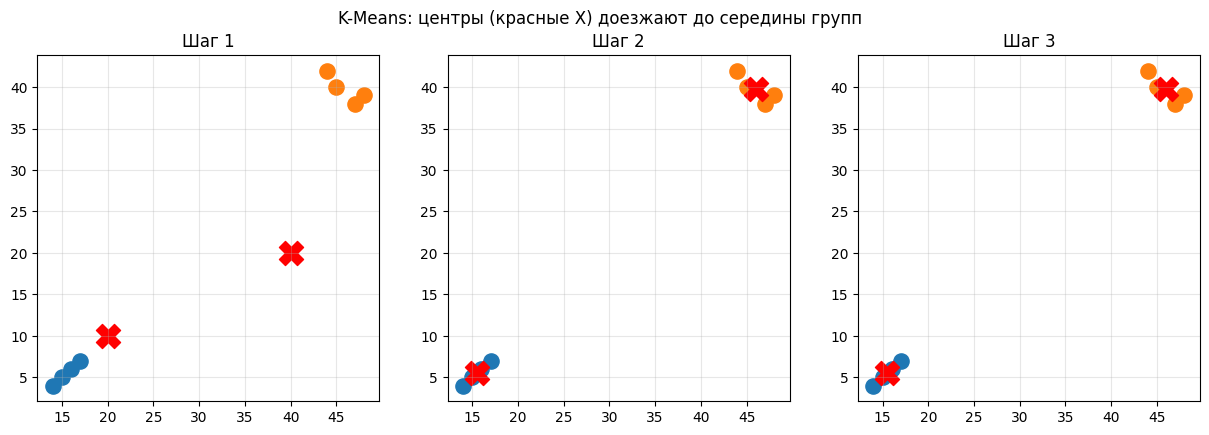

Финальные центры:
 [[15.5  5.5]
 [46.  39.8]]


In [8]:
# Прокрутим 3 итерации и нарисуем каждый шаг
colors = ['tab:blue', 'tab:orange']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for step in range(3):
    labels = assign(pts, centers)
    ax = axes[step]
    for i in range(2):
        grp = pts[labels == i]
        ax.scatter(grp[:, 0], grp[:, 1], c=colors[i], s=120)
    ax.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=300)
    ax.set_title(f'Шаг {step + 1}'); ax.grid(True, alpha=0.3)
    centers = move(pts, labels, 2)
plt.suptitle('K-Means: центры (красные X) доезжают до середины групп')
plt.show()
print('Финальные центры:\n', centers.round(1))

**Вопрос:** куда за несколько итераций смещаются центры K-Means и в какой момент алгоритм останавливается?

---
## 5. Иерархическая кластеризация и дендрограмма

Второй метод — **иерархическая кластеризация**. Здесь число K заранее задавать **не требуется**.

Принцип:

1. Сначала **каждый объект — отдельная группа** (8 точек — 8 групп).
2. Находятся **две ближайшие** группы и **склеиваются** в одну.
3. Шаг 2 повторяется, пока все не сольются в одну группу.

Историю склеиваний рисуют деревом — **дендрограммой**. Читают её так: внизу отдельные объекты (листья); линии **снизу вверх** показывают порядок склеек; **высота** перекладины — расстояние между группами в момент склейки (низкая высота — высокая похожесть).

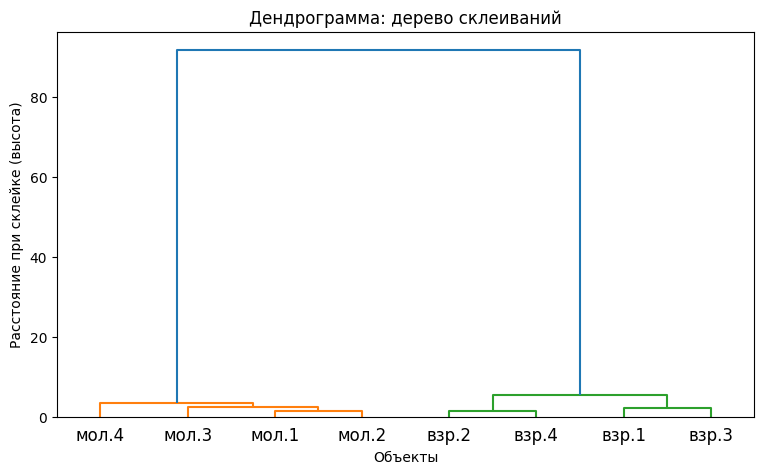

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

# linkage считает, кого с кем и в каком порядке склеивать;
# 'ward' склеивает так, чтобы группы были компактными
link = linkage(pts, method='ward')
labels_txt = ['мол.1', 'мол.2', 'мол.3', 'мол.4', 'взр.1', 'взр.2', 'взр.3', 'взр.4']

plt.figure(figsize=(9, 5))
dendrogram(link, labels=labels_txt)
plt.title('Дендрограмма: дерево склеиваний')
plt.xlabel('Объекты'); plt.ylabel('Расстояние при склейке (высота)')
plt.show()

**Вопрос:** почему верхняя перекладина дендрограммы такая высокая — о чём это говорит про молодых и взрослых?

> **А если** нужно получить из дерева ровно 2 группы — как это сделать, не строя K-Means заново? Дерево можно «разрезать» горизонтально функцией `fcluster`.

In [10]:
from scipy.cluster.hierarchy import fcluster

groups = fcluster(link, t=2, criterion='maxclust')
print('Номера групп для 8 точек:', groups)

Номера групп для 8 точек: [1 1 1 1 2 2 2 2]


**Вывод:** первые 4 точки (молодые) получили один номер, последние 4 (взрослые) — другой. Разрез дерева ниже верхней перекладины дал ровно **2 группы** — те же, что и на глаз.

---
## 6. Сколько групп выбрать: метод локтя

Частый вопрос — **на сколько групп делить**: 2, 3, 5? Иногда ответ виден по графику или дендрограмме. Есть и числовой подход — **метод локтя**.

Для каждого K считают, насколько компактно точки сидят вокруг своих центров. Эта величина — **инерция** (сумма расстояний от точек до их центров).
- С ростом числа групп инерция уменьшается (точки ближе к центрам).
- С некоторого момента добавление групп даёт незначительный выигрыш.

Точка перелома на графике похожа на **согнутый локоть** — в ней и останавливаются.

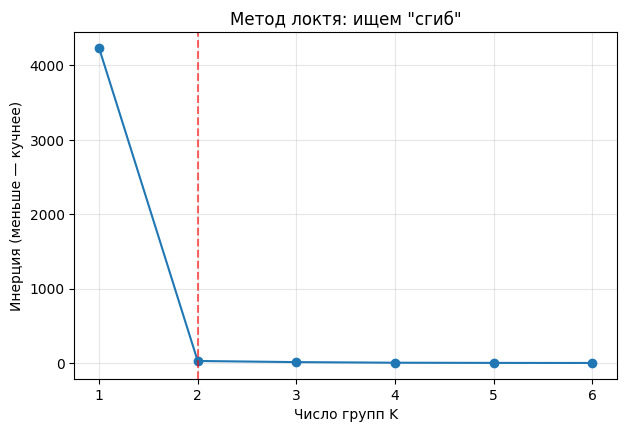

Инерция для K=1,2,3...: [4235, 29, 14, 6, 3, 2]


In [11]:
from sklearn.cluster import KMeans

inertias = []
Ks = range(1, 7)
for k in Ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(pts)
    inertias.append(model.inertia_)

plt.figure(figsize=(7, 4.5))
plt.plot(list(Ks), inertias, marker='o')
plt.xlabel('Число групп K'); plt.ylabel('Инерция (меньше — кучнее)')
plt.title('Метод локтя: ищем "сгиб"')
plt.axvline(2, color='red', linestyle='--', alpha=0.6)
plt.grid(True, alpha=0.3)
plt.show()
print('Инерция для K=1,2,3...:', [round(x) for x in inertias])

**Вопрос:** по графику метода локтя — на каком K следует остановиться и по какому признаку это видно?

> **А если** данные измерены в разных единицах — например, возраст (годы) и доход (сотни тысяч)? Тогда признак с большими числами «перетянет» расстояние на себя. На практике перед кластеризацией признаки часто приводят к одной шкале (**стандартизация**), чтобы ни один не доминировал только из-за масштаба. Этот приём отрабатывается на практике следующего занятия.

---
## Итог занятия

Что прошли:

- **Кластеризация** — поиск естественных групп без заранее заданных меток (обучение без учителя).
- **Признак и расстояние** — объект описывается числами; похожесть измеряется расстоянием (евклидовым или манхэттенским): меньше расстояние — больше похожесть.
- **Центроид** — среднее группы по каждому признаку, короткий «портрет» группы.
- **K-Means** — задаём число групп K, центры доезжают до середины групп за несколько итераций.
- **Иерархическая кластеризация** и **дендрограмма** — склеиваем ближайшие группы снизу вверх; число K заранее не нужно, дерево можно разрезать `fcluster`.
- **Метод локтя** — число групп выбирают по точке перелома графика инерции.

**Главная мысль: похожесть — это малое расстояние, группа — это её центр, а число групп подсказывают дендрограмма и локоть.**